In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Wildlife Strike Damage Prediction using Random Forest

This notebook predicts aircraft damage from wildlife strikes using a Random Forest ensemble method.

In [2]:
# Load the data
train_path = 'train.csv/train.csv'
test_path = 'test.csv/test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)
print("\nFirst few rows of training data:")
print(train_df.head())
print("\nTarget variable distribution:")
print(train_df['INDICATED_DAMAGE'].value_counts())

Training set shape: (307178, 55)
Test set shape: (34131, 54)

First few rows of training data:
   INDEX_NR INCIDENT_DATE  INCIDENT_MONTH  INCIDENT_YEAR  TIME TIME_OF_DAY  \
0   1410120      12/13/93              12           1993   NaN         Day   
1    709688        2/1/10               2           2010  5:00       Night   
2    730841        5/9/12               5           2012  2:00       Night   
3    654676       10/8/02              10           2002   NaN         NaN   
4    629708        2/3/97               2           1997   NaN        Dawn   

  AIRPORT_ID                     AIRPORT  LATITUDE   LONGITUDE  ... NUM_SEEN  \
0       TJSJ       LUIS MUNOZ MARIN INTL  18.43942   -66.00183  ...   10-Feb   
1       WMKK           KUALA LUMPUR INTL  2.745578  101.709917  ...      NaN   
2       KSDF  MUHAMMAD ALI INTERNATIONAL  38.17439     -85.736  ...      NaN   
3       KLAX            LOS ANGELES INTL  33.94254  -118.40807  ...      NaN   
4       PHLI                  LIHUE 

## Data Exploration and Preprocessing

In [3]:
# Check for missing values and data types
print("Missing values in training set:")
print(train_df.isnull().sum())
print("\nData types:")
print(train_df.dtypes)

Missing values in training set:
INDEX_NR                     0
INCIDENT_DATE                0
INCIDENT_MONTH               0
INCIDENT_YEAR                0
TIME                    109252
TIME_OF_DAY             133971
AIRPORT_ID                   0
AIRPORT                      0
LATITUDE                 40744
LONGITUDE                40747
RUNWAY                   75585
STATE                    40744
FAAREGION                40744
LOCATION                267960
OPID                         0
OPERATOR                     0
REG                     118982
FLT                     161435
AIRCRAFT                     0
AMA                      88896
AMO                     116813
EMA                     102421
EMO                     113176
AC_CLASS                 87315
AC_MASS                  87446
TYPE_ENG                 87786
NUM_ENGS                 87697
ENG_1_POS                87717
ENG_2_POS               102509
ENG_3_POS               294822
ENG_4_POS               303909
PHASE_O

In [4]:
# Feature Engineering and Preprocessing
def preprocess_data(df, is_training=True):
    """
    Preprocess the wildlife strike data for modeling
    """
    df_processed = df.copy()
    
    # Drop columns with excessive missing values or that won't be useful for prediction
    cols_to_drop = ['INDEX_NR', 'INCIDENT_DATE', 'REMARKS', 'COMMENTS', 'LUPDATE', 
                    'TRANSFER', 'BIRD_BAND_NUMBER', 'REG', 'FLT', 'INCIDENT_YEAR']
    df_processed = df_processed.drop(columns=[col for col in cols_to_drop if col in df_processed.columns], errors='ignore')
    
    # Separate features and target (if available)
    target = None
    if is_training:
        target = df_processed['INDICATED_DAMAGE']
        df_processed = df_processed.drop('INDICATED_DAMAGE', axis=1)
    
    # Handle numeric columns with missing values - fill with median
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)
    
    # Handle categorical columns - fill with 'Unknown'
    categorical_cols = df_processed.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        df_processed[col].fillna('Unknown', inplace=True)
    
    # Convert categorical variables to numeric
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        label_encoders[col] = le
    
    return df_processed, target, label_encoders

# Apply preprocessing
X_train, y_train, label_encoders = preprocess_data(train_df, is_training=True)
X_test, _, _ = preprocess_data(test_df, is_training=False)

print("Processed training features shape:", X_train.shape)
print("Processed test features shape:", X_test.shape)
print("\nFeature columns:")
print(X_train.columns.tolist())
print("\nClass distribution in training set:")
print(y_train.value_counts())
print(f"Proportion of damage class: {y_train.sum() / len(y_train):.4f}")

Processed training features shape: (307178, 44)
Processed test features shape: (34131, 44)

Feature columns:
['INCIDENT_MONTH', 'TIME', 'TIME_OF_DAY', 'AIRPORT_ID', 'AIRPORT', 'LATITUDE', 'LONGITUDE', 'RUNWAY', 'STATE', 'FAAREGION', 'LOCATION', 'OPID', 'OPERATOR', 'AIRCRAFT', 'AMA', 'AMO', 'EMA', 'EMO', 'AC_CLASS', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'SPEED', 'DISTANCE', 'SKY', 'PRECIPITATION', 'SPECIES_ID', 'SPECIES', 'OUT_OF_RANGE_SPECIES', 'REMAINS_COLLECTED', 'REMAINS_SENT', 'WARNED', 'NUM_SEEN', 'NUM_STRUCK', 'SIZE', 'ENROUTE_STATE', 'SOURCE', 'PERSON']

Class distribution in training set:
INDICATED_DAMAGE
0    287651
1     19527
Name: count, dtype: int64
Proportion of damage class: 0.0636


## Random Forest Model Training

Training a Random Forest ensemble to predict wildlife strike damage with balanced accuracy optimization.

In [5]:
# Split training data for validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Training set size: {X_tr.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Class distribution in training split: {pd.Series(y_tr).value_counts().to_dict()}")
print(f"Class distribution in validation split: {pd.Series(y_val).value_counts().to_dict()}")

Training set size: 245742
Validation set size: 61436
Class distribution in training split: {0: 230120, 1: 15622}
Class distribution in validation split: {0: 57531, 1: 3905}


Training Random Forest model...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   18.0s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   19.8s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s


Model training complete!


[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.1s finished



VALIDATION SET - COMPREHENSIVE ACCURACY SCORES
Standard Accuracy:        0.8810 (88.10%)
Balanced Accuracy:        0.7936 (79.36%)
Precision Score:          0.3070
Recall Score:             0.6935
F1-Score:                 0.4256
ROC-AUC Score:            0.9016

Detailed Classification Report (Validation Set):
              precision    recall  f1-score   support

   No Damage       0.98      0.89      0.93     57531
      Damage       0.31      0.69      0.43      3905

    accuracy                           0.88     61436
   macro avg       0.64      0.79      0.68     61436
weighted avg       0.93      0.88      0.90     61436


Confusion Matrix:
[[51418  6113]
 [ 1197  2708]]


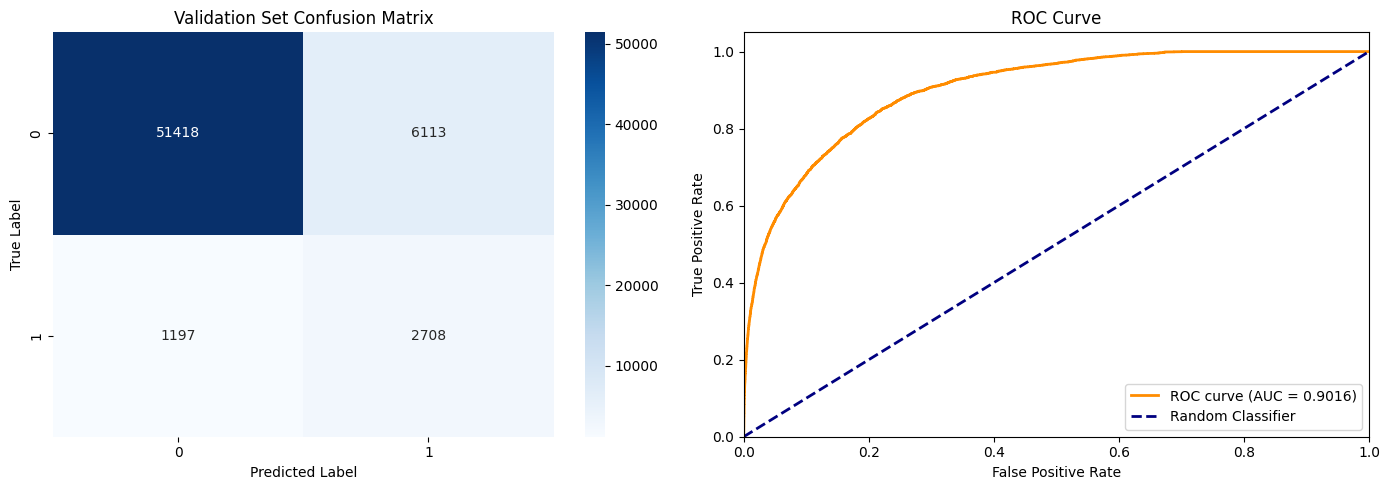

In [6]:
# Additional metrics import
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Train Random Forest with balanced class weights
rf_model = RandomForestClassifier(
    n_estimators=200,           # Number of trees in the forest
    max_depth=15,               # Maximum depth of trees
    min_samples_split=10,       # Minimum samples required to split
    min_samples_leaf=5,         # Minimum samples required at leaf node
    max_features='sqrt',        # Number of features to consider at each split
    class_weight='balanced',    # Balanced weights to handle class imbalance
    random_state=42,
    n_jobs=-1,                  # Use all available processors
    verbose=1
)

# Train the model
print("Training Random Forest model...")
rf_model.fit(X_tr, y_tr)
print("Model training complete!")

# Make predictions on validation set
y_val_pred = rf_model.predict(X_val)
y_val_pred_proba = rf_model.predict_proba(X_val)

# Calculate comprehensive accuracy metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_balanced_acc = balanced_accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, zero_division=0)
val_recall = recall_score(y_val, y_val_pred, zero_division=0)
val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
val_roc_auc = roc_auc_score(y_val, y_val_pred_proba[:, 1])

# Print comprehensive accuracy scores
print("\n" + "="*60)
print("VALIDATION SET - COMPREHENSIVE ACCURACY SCORES")
print("="*60)
print(f"Standard Accuracy:        {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"Balanced Accuracy:        {val_balanced_acc:.4f} ({val_balanced_acc*100:.2f}%)")
print(f"Precision Score:          {val_precision:.4f}")
print(f"Recall Score:             {val_recall:.4f}")
print(f"F1-Score:                 {val_f1:.4f}")
print(f"ROC-AUC Score:            {val_roc_auc:.4f}")
print("="*60)

# Print detailed classification report
print("\nDetailed Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred, target_names=['No Damage', 'Damage']))

# Print confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix and ROC curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Validation Set Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba[:, 1])
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {val_roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

Top 20 Most Important Features:
            Feature  Importance
40             SIZE    0.177062
32       SPECIES_ID    0.105253
13         AIRCRAFT    0.072001
18         AC_CLASS    0.061214
14              AMA    0.042325
19          AC_MASS    0.039080
20         TYPE_ENG    0.038512
12         OPERATOR    0.032994
15              AMO    0.029839
33          SPECIES    0.029251
27           HEIGHT    0.027647
11             OPID    0.024700
26  PHASE_OF_FLIGHT    0.024468
42           SOURCE    0.023989
1              TIME    0.019457
43           PERSON    0.017585
28            SPEED    0.015529
5          LATITUDE    0.014929
7            RUNWAY    0.014782
0    INCIDENT_MONTH    0.014486


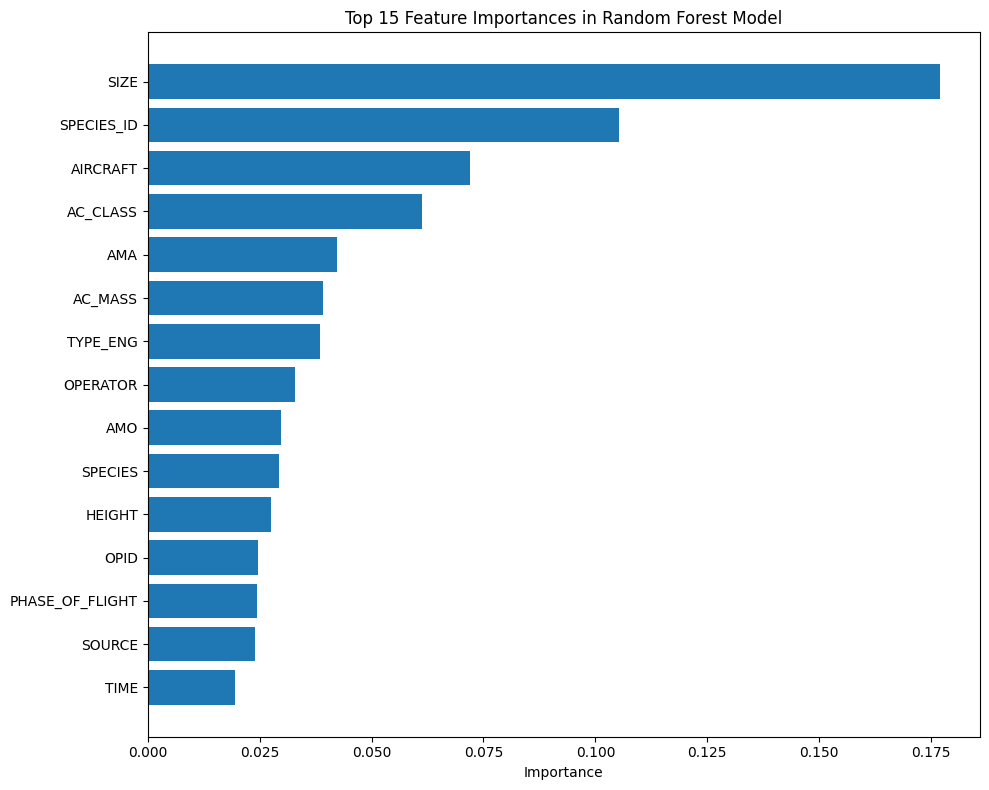

In [7]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 20 Most Important Features:")
print(feature_importance.head(20))

# Plot feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances in Random Forest Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Cross-Validation and Test Predictions

In [7]:
# Cross-validation with multiple scoring metrics
from sklearn.model_selection import cross_validate

scoring_metrics = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

print("Performing 5-fold cross-validation with multiple metrics...")
cv_results = cross_validate(
    rf_model, X_train, y_train, 
    cv=5, 
    scoring=scoring_metrics,
    n_jobs=-1
)

# Print cross-validation results
print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS (5-Fold)")
print("="*60)
for metric, scores in cv_results.items():
    if metric.startswith('test_'):
        metric_name = metric.replace('test_', '').replace('_', ' ').title()
        print(f"{metric_name:20} | Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")
        print(f"                     | Fold scores: {[f'{s:.4f}' for s in scores]}")
print("="*60)

# Train on full training set for final predictions
print("\nRetraining on full dataset for final predictions...")
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)
print("Final model training complete!")

Performing 5-fold cross-validation with multiple metrics...

CROSS-VALIDATION RESULTS (5-Fold)
Accuracy             | Mean: 0.8810 | Std: 0.0015
                     | Fold scores: ['0.8816', '0.8830', '0.8814', '0.8806', '0.8784']
Balanced Accuracy    | Mean: 0.7980 | Std: 0.0053
                     | Fold scores: ['0.7942', '0.8061', '0.8027', '0.7930', '0.7942']
Precision            | Mean: 0.3086 | Std: 0.0045
                     | Fold scores: ['0.3083', '0.3155', '0.3111', '0.3059', '0.3023']
Recall               | Mean: 0.7030 | Std: 0.0103
                     | Fold scores: ['0.6940', '0.7179', '0.7125', '0.6927', '0.6978']
F1                   | Mean: 0.4289 | Std: 0.0060
                     | Fold scores: ['0.4270', '0.4384', '0.4331', '0.4244', '0.4218']
Roc Auc              | Mean: 0.9040 | Std: 0.0028
                     | Fold scores: ['0.9017', '0.9076', '0.9068', '0.9035', '0.9006']

Retraining on full dataset for final predictions...
Final model training complete!

In [8]:
# Generate predictions on test set
print("Generating predictions on test set...")
y_test_pred = rf_final.predict(X_test)
y_test_pred_proba = rf_final.predict_proba(X_test)

print(f"Predictions shape: {y_test_pred.shape}")
print(f"Prediction distribution: {pd.Series(y_test_pred).value_counts().to_dict()}")
print(f"Proportion of damage predictions: {y_test_pred.sum() / len(y_test_pred):.4f}")

Generating predictions on test set...
Predictions shape: (34131,)
Prediction distribution: {0: 28315, 1: 5816}
Proportion of damage predictions: 0.1704


In [9]:
# Calculate accuracy metrics on training set
print("\n" + "="*60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*60)

# Training set accuracy
y_train_pred = rf_final.predict(X_train)
y_train_pred_proba = rf_final.predict_proba(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_balanced_acc = balanced_accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, zero_division=0)
train_recall = recall_score(y_train, y_train_pred, zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
train_roc_auc = roc_auc_score(y_train, y_train_pred_proba[:, 1])

print("\nTraining Set Metrics:")
print(f"  Standard Accuracy:        {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  Balanced Accuracy:        {train_balanced_acc:.4f} ({train_balanced_acc*100:.2f}%)")
print(f"  Precision:                {train_precision:.4f}")
print(f"  Recall:                   {train_recall:.4f}")
print(f"  F1-Score:                 {train_f1:.4f}")
print(f"  ROC-AUC:                  {train_roc_auc:.4f}")

print("\n" + "-"*60)
print("="*60)


FINAL MODEL PERFORMANCE SUMMARY

Training Set Metrics:
  Standard Accuracy:        0.8940 (89.40%)
  Balanced Accuracy:        0.8848 (88.48%)
  Precision:                0.3619
  Recall:                   0.8743
  F1-Score:                 0.5119
  ROC-AUC:                  0.9585

------------------------------------------------------------


## Generate Submission File

In [10]:
# Create submission dataframe
submission_df = pd.DataFrame({
    'INDEX_NR': test_df['INDEX_NR'],
    'INDICATED_DAMAGE': y_test_pred
})

# Save submission file
submission_path = 'submission.csv'
submission_df.to_csv(submission_path, index=False)
print(f"Submission file saved to {submission_path}")

print("\nFirst 10 rows of submission:")
print(submission_df.head(10))

print(f"\nTotal predictions: {len(submission_df)}")
print(f"Damage predictions (1): {(submission_df['INDICATED_DAMAGE'] == 1).sum()}")
print(f"No damage predictions (0): {(submission_df['INDICATED_DAMAGE'] == 0).sum()}")

Submission file saved to submission.csv

First 10 rows of submission:
   INDEX_NR  INDICATED_DAMAGE
0   9000000                 0
1   9000001                 0
2   9000002                 0
3   9000003                 0
4   9000004                 1
5   9000005                 1
6   9000006                 0
7   9000007                 0
8   9000008                 0
9   9000009                 0

Total predictions: 34131
Damage predictions (1): 5816
No damage predictions (0): 28315


## Model Summary

In [11]:
print("="*60)
print("RANDOM FOREST MODEL SUMMARY")
print("="*60)
print(f"\nModel Configuration:")
print(f"  - Number of estimators: 200")
print(f"  - Max depth: 15")
print(f"  - Min samples split: 10")
print(f"  - Min samples leaf: 5")
print(f"  - Class weight: balanced")
print(f"\nTraining Data:")
print(f"  - Total samples: {len(X_train)}")
print(f"  - Features: {X_train.shape[1]}")
print(f"  - Class 0 (No Damage): {(y_train == 0).sum()}")
print(f"  - Class 1 (Damage): {(y_train == 1).sum()}")
print(f"\nValidation Performance:")
print(f"  - Balanced Accuracy: {val_balanced_acc:.4f}")
print(f"  - CV Balanced Accuracy (mean): {cv_scores['test_score'].mean():.4f}")
print(f"  - CV Balanced Accuracy (std): {cv_scores['test_score'].std():.4f}")
print(f"\nTest Predictions:")
print(f"  - Total test samples: {len(submission_df)}")
print(f"  - Damage predictions: {(submission_df['INDICATED_DAMAGE'] == 1).sum()}")
print(f"  - No damage predictions: {(submission_df['INDICATED_DAMAGE'] == 0).sum()}")
print(f"\nSubmission saved to: {submission_path}")
print("="*60)

RANDOM FOREST MODEL SUMMARY

Model Configuration:
  - Number of estimators: 200
  - Max depth: 15
  - Min samples split: 10
  - Min samples leaf: 5
  - Class weight: balanced

Training Data:
  - Total samples: 307178
  - Features: 44
  - Class 0 (No Damage): 287651
  - Class 1 (Damage): 19527

Validation Performance:
  - Balanced Accuracy: 0.7936
  - CV Balanced Accuracy (mean): 0.7980
  - CV Balanced Accuracy (std): 0.0053

Test Predictions:
  - Total test samples: 34131
  - Damage predictions: 5816
  - No damage predictions: 28315

Submission saved to: submission.csv
